In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 
import warnings 
warnings.filterwarnings('ignore')

data cleaning


In [2]:
import os

In [3]:
dataset_path = r"C:\Users\harsh\OneDrive\Desktop\dataset"

images = []

for root, dirs, files in os.walk(dataset_path):
    for file in files:
        if file.lower().endswith((".jpg", ".jpeg", ".png", ".webp")):
            images.append([
                file,
                os.path.basename(root),
                os.path.join(root, file)
            ])

data = pd.DataFrame(images, columns=["filename", "class", "path"])

In [4]:
data

,filename,class,path
0,1.jpg,Accident,C:\Users\harsh\OneDrive\Desktop\dataset\firee\...
1,10.jpg,Accident,C:\Users\harsh\OneDrive\Desktop\dataset\firee\...
2,100.jpg,Accident,C:\Users\harsh\OneDrive\Desktop\dataset\firee\...
3,1000.jpg,Accident,C:\Users\harsh\OneDrive\Desktop\dataset\firee\...
4,1001.jpg,Accident,C:\Users\harsh\OneDrive\Desktop\dataset\firee\...
...,...,...,...
12906,Traffic_Roads 5 (95).jpg,traffic road,C:\Users\harsh\OneDrive\Desktop\dataset\road\R...
12907,Traffic_Roads 5 (96).jpg,traffic road,C:\Users\harsh\OneDrive\Desktop\dataset\road\R...
12908,Traffic_Roads 5 (97).jpg,traffic road,C:\Users\harsh\OneDrive\Desktop\dataset\road\R...
12909,Traffic_Roads 5 (98).jpg,traffic road,C:\Users\harsh\OneDrive\Desktop\dataset\road\R...


In [5]:
data.head()

,filename,class,path
0,1.jpg,Accident,C:\Users\harsh\OneDrive\Desktop\dataset\firee\...
1,10.jpg,Accident,C:\Users\harsh\OneDrive\Desktop\dataset\firee\...
2,100.jpg,Accident,C:\Users\harsh\OneDrive\Desktop\dataset\firee\...
3,1000.jpg,Accident,C:\Users\harsh\OneDrive\Desktop\dataset\firee\...
4,1001.jpg,Accident,C:\Users\harsh\OneDrive\Desktop\dataset\firee\...


In [6]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 12911 entries, 0 to 12910
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   filename  12911 non-null  str  
 1   class     12911 non-null  str  
 2   path      12911 non-null  str  
dtypes: str(3)
memory usage: 302.7 KB


In [7]:
data.describe()

,filename,class,path
count,12911,12911,12911
unique,11941,13,12911
top,1.jpg,Accident,C:\Users\harsh\OneDrive\Desktop\dataset\firee\...
freq,4,6191,1


In [8]:
data.isnull().sum()

filename    0
class       0
path        0
dtype: int64

corrupted image 


In [9]:
from PIL import Image

correcpt image
 

In [10]:
corrupted = []

for path in data["path"]:
    try:
        img = Image.open(path)
        img.verify()
    except:
        corrupted.append(path)

print("Corrupted images:", len(corrupted))

Corrupted images: 0


In [11]:
data["class"].value_counts()

class
Accident           6191
images             2641
fire_images         755
Potholes            480
blocked road        388
Clean road          370
normal              352
potholes            329
traffic road        300
Image               290
Mask                290
Smooth road         281
non_fire_images     244
Name: count, dtype: int64

<Axes: xlabel='class'>

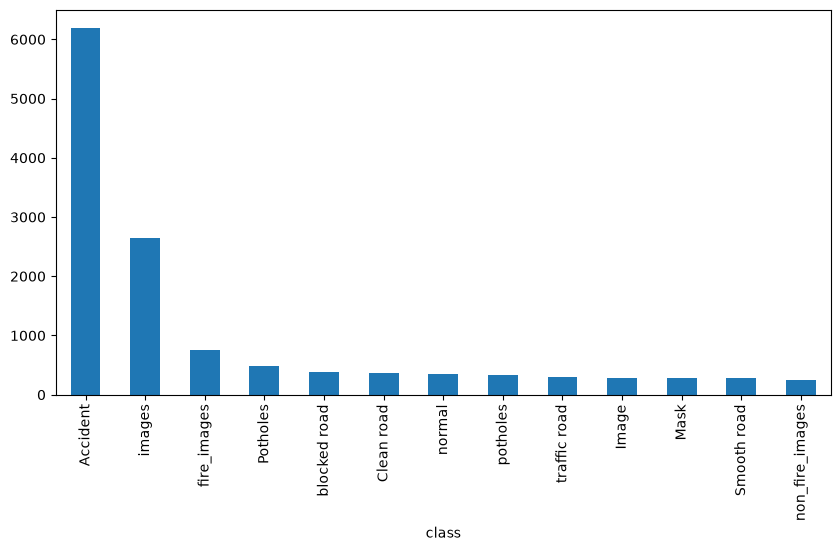

In [12]:
data["class"].value_counts().plot(kind="bar", figsize=(10, 5))

In [13]:
data["class"].unique()

<StringArray>
[       'Accident',          'images',     'fire_images', 'non_fire_images',
           'Image',            'Mask',          'normal',        'potholes',
    'blocked road',      'Clean road',        'Potholes',     'Smooth road',
    'traffic road']
Length: 13, dtype: str

In [14]:
classes = data["class"].unique()

image visual

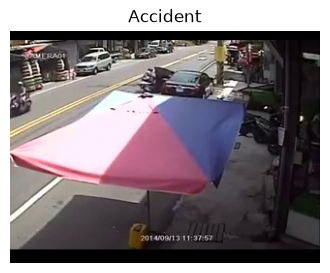

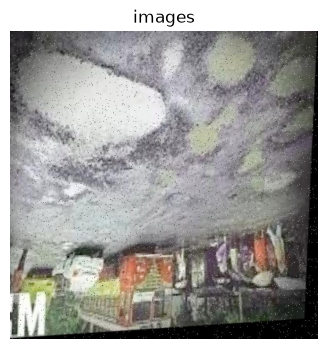

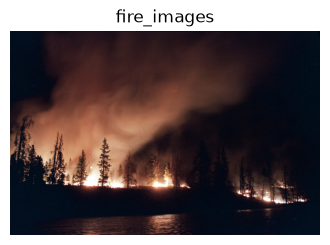

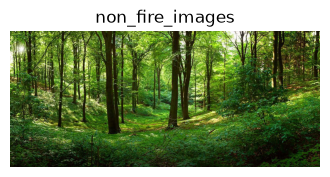

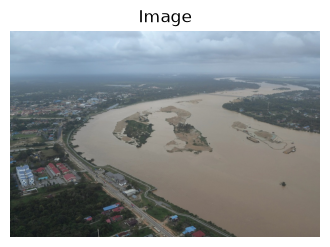

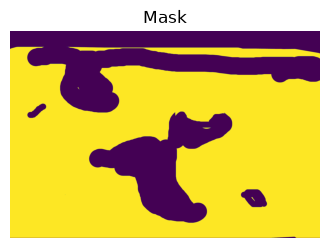

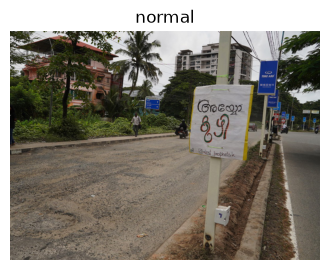

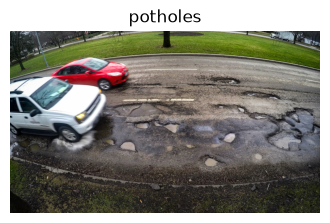

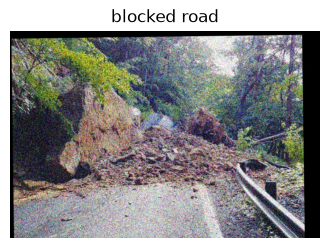

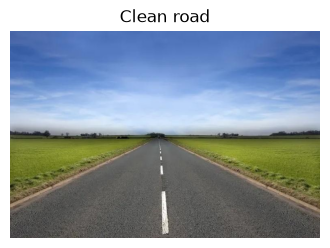

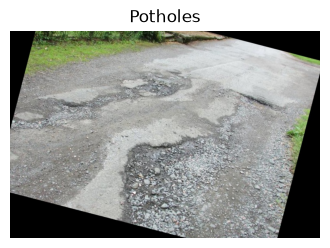

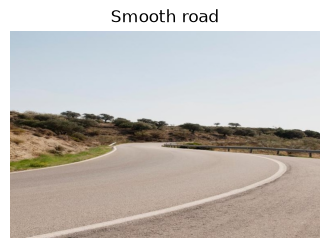

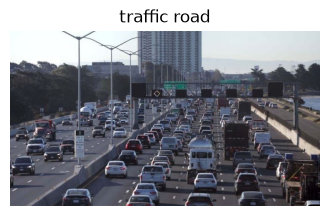

In [15]:
for cls in classes:
    class_data = data[data["class"] == cls]
    sample = class_data.sample(1).iloc[0]

    img = Image.open(sample["path"])

    plt.figure(figsize=(4,4))
    plt.imshow(img)
    plt.title(cls)
    plt.axis("off")
    plt.show()

In [16]:
data["path"].apply(lambda x: Image.open(x).size).value_counts().head(10)

path
(320, 240)     6191
(640, 640)     2642
(765, 512)     1091
(765, 510)      148
(765, 430)       94
(765, 574)       58
(1280, 720)      47
(512, 765)       43
(1200, 800)      40
(600, 338)       30
Name: count, dtype: int64

In [17]:

data["size"] = data["path"]

In [18]:
data["width"] = data["size"].apply(lambda x: x[0])
data["height"] = data["size"].apply(lambda x: x[1])

data[["width", "height"]].describe()

,width,height
count,12911,12911
unique,1,1
top,C,:
freq,12911,12911


In [19]:
data["width"] = pd.to_numeric(data["width"], errors="coerce")
data["height"] = pd.to_numeric(data["height"], errors="coerce")

data[(data["width"] < 100) | (data["height"] < 100)]

,filename,class,path,size,width,height


In [20]:
data[data["width"] > 2000][["filename", "class", "width", "height"]]

,filename,class,width,height


check imbalancing 


In [21]:
data["class"].value_counts().describe()

count      13.000000
mean      993.153846
std      1688.131701
min       244.000000
25%       290.000000
50%       352.000000
75%       480.000000
max      6191.000000
Name: count, dtype: float64

In [22]:
(data["class"].value_counts(normalize=True) * 100).round(2)

class
Accident           47.95
images             20.46
fire_images         5.85
Potholes            3.72
blocked road        3.01
Clean road          2.87
normal              2.73
potholes            2.55
traffic road        2.32
Image               2.25
Mask                2.25
Smooth road         2.18
non_fire_images     1.89
Name: proportion, dtype: float64

70% → Train
15% → Validation
15% → Test

In [73]:
from sklearn.model_selection import train_test_split

In [72]:
data["class"] = data["class"].replace({
    "Potholes": "potholes",
    "Clean road": "normal_road",
    "Smooth road": "normal_road",
    "normal": "normal_road"
})

In [82]:
train_data, test_data = train_test_split(data, test_size=0.2, stratify=data["class"], random_state=42)

In [83]:
val_data, test_data = train_test_split(test_data, test_size=0.5, stratify=test_data["class"], random_state=42)

In [84]:
print("TRAIN:" , len(train_data))
print(train_data["class"].value_counts())
print("\nTrain %")
print((train_data["class"].value_counts(normalize=True) * 100).round(2))

print("\nVALIDATION:" , len(val_data))
print(val_data["class"].value_counts())
print("\nvalidation %")
print((val_data["class"].value_counts(normalize=True) * 100).round(2))

print("\nTEST:" , len(test_data))
print(test_data["class"].value_counts())
print("test %")
print((test_data["class"].value_counts(normalize=True) * 100).round(2))

TRAIN: 10328
class
Accident           4953
images             2113
normal_road         802
potholes            647
fire_images         604
blocked road        310
traffic road        240
Mask                232
Image               232
non_fire_images     195
Name: count, dtype: int64

Train %
class
Accident           47.96
images             20.46
normal_road         7.77
potholes            6.26
fire_images         5.85
blocked road        3.00
traffic road        2.32
Mask                2.25
Image               2.25
non_fire_images     1.89
Name: proportion, dtype: float64

VALIDATION: 1291
class
Accident           619
images             264
normal_road        100
potholes            81
fire_images         75
blocked road        39
traffic road        30
Image               29
Mask                29
non_fire_images     25
Name: count, dtype: int64

validation %
class
Accident           47.95
images             20.45
normal_road         7.75
potholes            6.27
fire_images      

In [85]:
print("Total:", len(data))
print("Train:", len(train_data))
print("Validation:", len(val_data))
print("Test:", len(test_data))

Total: 12911
Train: 10328
Validation: 1291
Test: 1292


image prepossesing

In [86]:
img = Image.open(train_data.iloc[0]["path"]).convert("RGB")

img = img.resize((224, 224))

img_array = np.array(img) / 255.0

In [87]:
print("Image shape:", img_array.shape)
print("Minimum pixel value:", img_array.min())
print("Maximum pixel value:" , img_array.max())

Image shape: (224, 224, 3)
Minimum pixel value: 0.0
Maximum pixel value: 1.0


labelencoding


In [88]:
from sklearn.preprocessing import LabelEncoder

In [89]:
label_encoder = LabelEncoder()
data["label"] = label_encoder.fit_transform(data["class"])

In [90]:
label_encoder = LabelEncoder()

train_data["label"] = label_encoder.fit_transform(train_data["class"])

val_data["label"] = label_encoder.transform(val_data["class"])

test_data["label"] = label_encoder.transform(test_data["class"])

In [107]:
print(label_encoder.classes_)
print("Total classes:", len(label_encoder.classes_))

['Accident' 'Image' 'Mask' 'blocked road' 'fire_images' 'images'
 'non_fire_images' 'normal_road' 'potholes' 'traffic road']
Total classes: 10


In [91]:
import tensorflow as tf

print(tf.__version__)


2.21.0


tensorflow dataset load


In [108]:
def load_image(path, label):
    img = tf.io.read_file(path)
    img = tf.image.decode_image(img, channels=3, expand_animations=False)
    img.set_shape([None, None, 3])
    img = tf.image.resize(img, (224, 224))
    img = img / 255.0
    return img, label


In [110]:
train_ds = tf.data.Dataset.from_tensor_slices(
    (train_data["path"].values, train_data["label"].values)
)

val_ds = tf.data.Dataset.from_tensor_slices(
    (val_data["path"].values, val_data["label"].values)
)

test_ds = tf.data.Dataset.from_tensor_slices(
    (test_data["path"].values, test_data["label"].values)
)

making batch


In [111]:
train_ds = train_ds.map(load_image).batch(32).prefetch(tf.data.AUTOTUNE)
val_ds = val_ds.map(load_image).batch(32).prefetch(tf.data.AUTOTUNE)
test_ds = test_ds.map(load_image).batch(32).prefetch(tf.data.AUTOTUNE)

In [112]:
for images, labels in train_ds.take(1):
    print(images.shape)
    print(labels.shape)

(32, 224, 224, 3)
(32,)


# machine learning part done 

Dataset load ✔️
Missing values check ✔️
Duplicate/noisy data checking ✔️
Classes check ✔️
Image sizes check ✔️
Labels encode ✔️
Train/Validation/Test split ✔️
Memory problem solve ✔️
TensorFlow tf.data pipeline start ✔️

# deep learning ( CNN model) ------>

Dataset → CNN Model → Training → Validation → Testing → Accuracy/Precision/Recall/F1 → Confusion Matrix → Save Model → Prediction

In [115]:
from tensorflow.keras import layers, models

In [116]:
model = models.Sequential()


In [117]:
model.add(layers.Conv2D(32, (3, 3), activation="relu", input_shape=(224, 224, 3)))
model.add(layers.MaxPooling2D(2, 2))

model.add(layers.Conv2D(32, (3, 3), activation="relu"))
model.add(layers.MaxPooling2D(2, 2))

model.add(layers.Conv2D(64, (3, 3), activation="relu"))
model.add(layers.MaxPooling2D(2, 2))

model.add(layers.Conv2D(128, (3, 3), activation="relu"))
model.add(layers.MaxPooling2D(2, 2))

In [118]:

model.add(layers.Flatten())

model.add(layers.Dense(128, activation="relu"))
model.add(layers.Dropout(0.5))

model.add(layers.Dense(10, activation="softmax"))

In [120]:
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_11 (Conv2D)              │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 109, 109, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 54, 54, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 52, 52, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 26, 26, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 24, 24, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 18432)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │     2,359,424 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,463,210 (9.40 MB)

 Trainable params: 2,463,210 (9.40 MB)

 Non-trainable params: 0 (0.00 B)

In [122]:
model.compile(optimizer='adam',loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [ ]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

Epoch 1/10


323/323 ━━━━━━━━━━━━━━━━━━━━ 295s 910ms/step - accuracy: 0.7715 - loss: 0.7740 - val_accuracy: 0.8644 - val_loss: 0.3968
Epoch 2/10
323/323 ━━━━━━━━━━━━━━━━━━━━ 337s 1s/step - accuracy: 0.8933 - loss: 0.3126 - val_accuracy: 0.8691 - val_loss: 0.5073
Epoch 3/10
323/323 ━━━━━━━━━━━━━━━━━━━━ 324s 1s/step - accuracy: 0.9399 - loss: 0.1807 - val_accuracy: 0.8970 - val_loss: 0.3863
Epoch 4/10
323/323 ━━━━━━━━━━━━━━━━━━━━ 353s 1s/step - accuracy: 0.9612 - loss: 0.1263 - val_accuracy: 0.9047 - val_loss: 0.3773
Epoch 5/10
323/323 ━━━━━━━━━━━━━━━━━━━━ 428s 1s/step - accuracy: 0.9788 - loss: 0.0708 - val_accuracy: 0.9009 - val_loss: 0.4009
Epoch 6/10
323/323 ━━━━━━━━━━━━━━━━━━━━ 355s 1s/step - accuracy: 0.9863 - loss: 0.0518 - val_accuracy: 0.8970 - val_loss: 0.4148
Epoch 7/10
323/323 ━━━━━━━━━━━━━━━━━━━━ 349s 1s/step - accuracy: 0.9862 - loss: 0.0505 - val_accuracy: 0.8869 - val_loss: 0.5786
Epoch 8/10
323/323 ━━━━━━━━━━━━━━━━━━━━ 326s 1s/step - accuracy: 0.9877 - loss: 0.0485 - val_accuracy: 0.

In [127]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True
)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=[early_stop]
)

Epoch 1/10
323/323 ━━━━━━━━━━━━━━━━━━━━ 190s 583ms/step - accuracy: 0.8358 - loss: 0.5221 - val_accuracy: 0.9040 - val_loss: 0.3549
Epoch 2/10
323/323 ━━━━━━━━━━━━━━━━━━━━ 189s 583ms/step - accuracy: 0.8738 - loss: 0.3800 - val_accuracy: 0.9218 - val_loss: 0.2685
Epoch 3/10
323/323 ━━━━━━━━━━━━━━━━━━━━ 176s 544ms/step - accuracy: 0.9003 - loss: 0.2955 - val_accuracy: 0.9233 - val_loss: 0.2394
Epoch 4/10
323/323 ━━━━━━━━━━━━━━━━━━━━ 168s 518ms/step - accuracy: 0.9189 - loss: 0.2418 - val_accuracy: 0.9365 - val_loss: 0.2178
Epoch 5/10
323/323 ━━━━━━━━━━━━━━━━━━━━ 159s 491ms/step - accuracy: 0.9285 - loss: 0.2039 - val_accuracy: 0.9349 - val_loss: 0.2217
Epoch 6/10
323/323 ━━━━━━━━━━━━━━━━━━━━ 163s 504ms/step - accuracy: 0.9443 - loss: 0.1720 - val_accuracy: 0.9380 - val_loss: 0.2122
Epoch 7/10
323/323 ━━━━━━━━━━━━━━━━━━━━ 416s 1s/step - accuracy: 0.9527 - loss: 0.1328 - val_accuracy: 0.9404 - val_loss: 0.2157
Epoch 8/10
323/323 ━━━━━━━━━━━━━━━━━━━━ 176s 543ms/step - accuracy: 0.9622 - lo

overfitting check

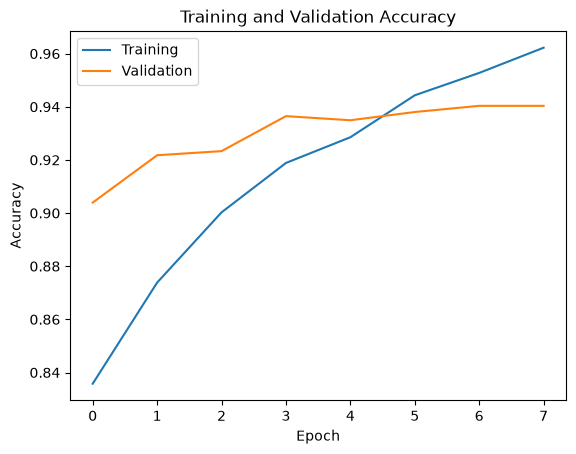

In [128]:
plt.plot(history.history["accuracy"])
plt.plot(history.history["val_accuracy"])


plt.title("Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(["Training", "Validation"])

plt.show()

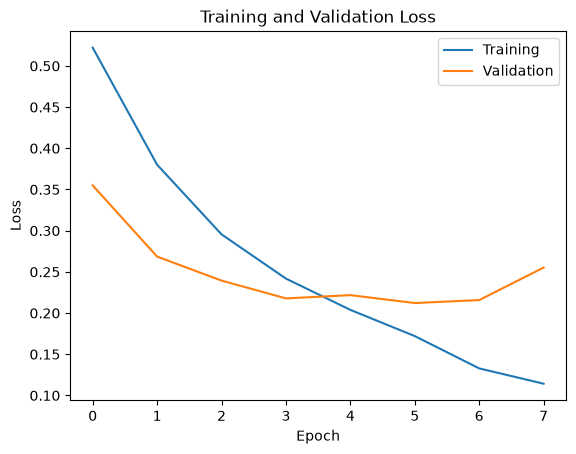

In [129]:
plt.plot(history.history["loss"])
plt.plot(history.history["val_loss"])

# plt.figure(figsize=(5, 5))
plt.title("Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(["Training", "Validation"])

plt.show()

In [130]:
test_loss, test_accuracy = model.evaluate(test_ds)

print("Test Accuracy:", test_accuracy)
print("Test Loss:", test_loss)

41/41 ━━━━━━━━━━━━━━━━━━━━ 6s 143ms/step - accuracy: 0.9265 - loss: 0.2229
Test Accuracy: 0.9264705777168274
Test Loss: 0.22287887334823608


In [131]:
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

In [132]:
y_true = []
y_pred = []

for images, labels in test_ds:
    predictions = model.predict(images, verbose=0)

    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(predictions, axis=1))

In [133]:
print(classification_report(y_true, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       619
           1       0.68      0.66      0.67        29
           2       0.97      1.00      0.98        29
           3       0.83      0.62      0.71        39
           4       0.91      0.89      0.90        76
           5       0.96      0.92      0.94       264
           6       0.95      0.88      0.91        24
           7       0.87      0.80      0.84       101
           8       0.61      0.86      0.71        81
           9       0.88      0.77      0.82        30

    accuracy                           0.93      1292
   macro avg       0.87      0.84      0.85      1292
weighted avg       0.93      0.93      0.93      1292



In [ ]:
print(label_encoder.classes_)

['Accident' 'Clean road' 'Image' 'Mask' 'Potholes' 'Smooth road'
 'blocked road' 'fire_images' 'images' 'non_fire_images' 'normal'
 'potholes' 'traffic road']


([<matplotlib.axis.YTick at 0x2d4547b2d50>,
 [Text(0, 0, 'Accident'),
  Text(0, 1, 'Image'),
  Text(0, 2, 'Mask'),
  Text(0, 3, 'blocked road'),
  Text(0, 4, 'fire_images'),
  Text(0, 5, 'images'),
  Text(0, 6, 'non_fire_images'),
  Text(0, 7, 'normal_road'),
  Text(0, 8, 'potholes'),
  Text(0, 9, 'traffic road')])

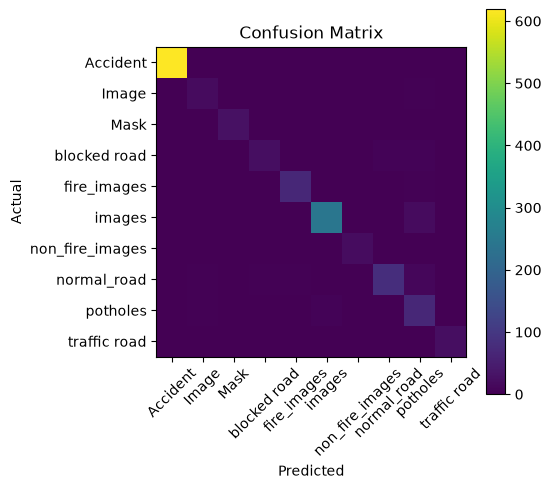

In [136]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(5, 5))
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.colorbar()

plt.xticks(range(len(label_encoder.classes_)), label_encoder.classes_, rotation=45)
plt.yticks(range(len(label_encoder.classes_)), label_encoder.classes_)


 problem  check --> Potholes  vs  potholes
Image     vs  images
Clean road / Smooth road / normal

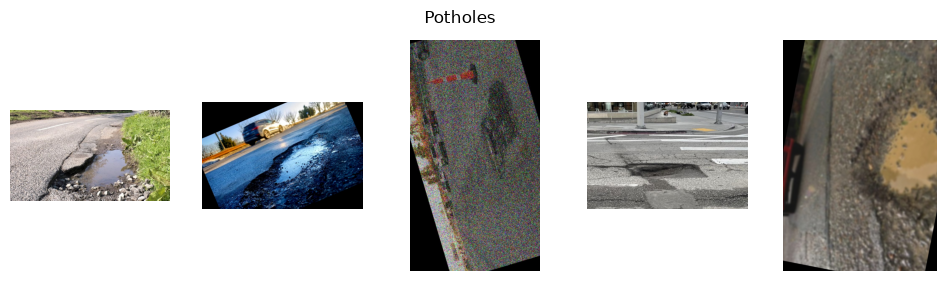

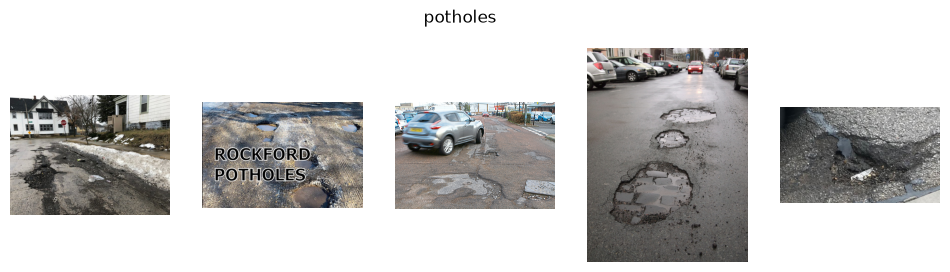

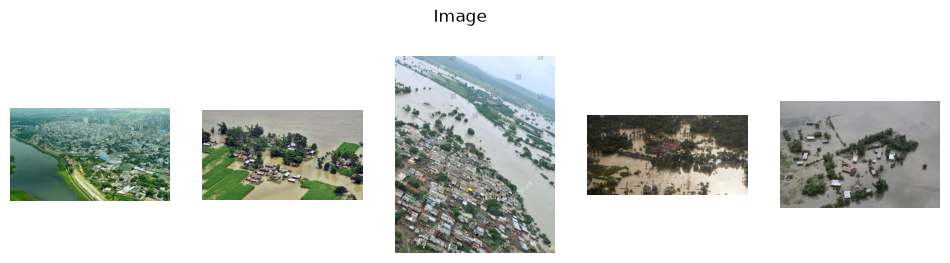

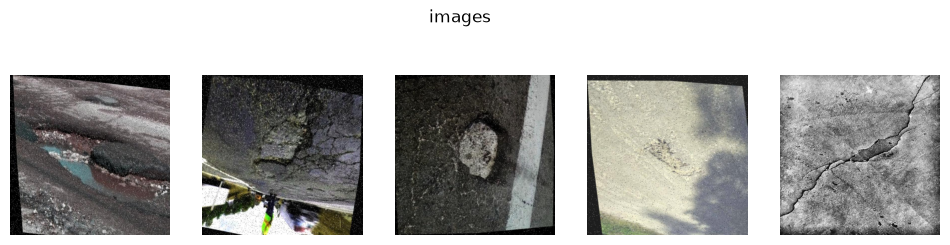

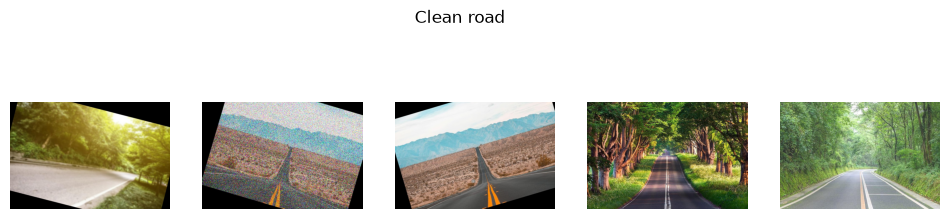

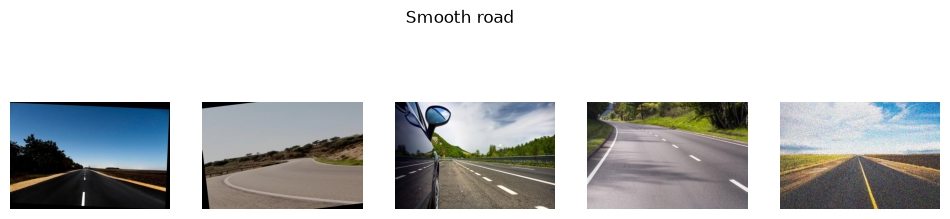

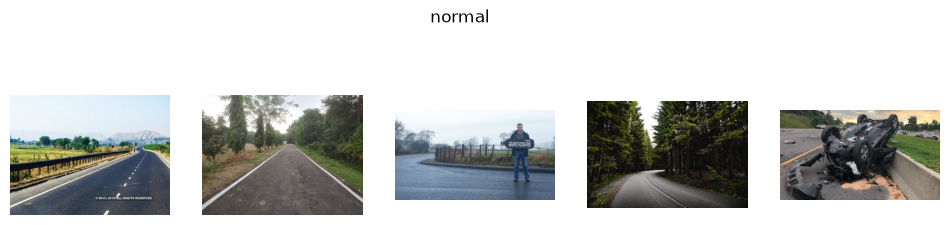

In [ ]:


classes_to_check = [
    "Potholes",
    "potholes",
    "Image",
    "images",
    "Clean road",
    "Smooth road",
    "normal"
]

for class_name in classes_to_check:
    
    sample = data[data["class"] == class_name].sample(
        min(5, len(data[data["class"] == class_name]))
    )

    plt.figure(figsize=(12, 3))
    plt.suptitle(class_name)

    for i, (_, row) in enumerate(sample.iterrows()):
        img = plt.imread(row["path"])

        plt.subplot(1, len(sample), i + 1)
        plt.imshow(img)
        plt.axis("off")

    plt.show()

Test Accuracy = 92.65%
Macro F1 = 0.85
Weighted F1 = 0.93

# MODEL SAVE 

In [13]:
model.save("disaster_model.keras")

print("Model saved successfully!")

Model saved successfully!


Deep learning end ------>>

✅ Image preprocessing
✅ TensorFlow tf.data pipeline
✅ CNN model build kiya
✅ Conv2D + MaxPooling layers
✅ Dense + Dropout
✅ 10-class classification
✅ Model training
✅ EarlyStopping
✅ Validation evaluation
✅ Test evaluation
✅ Classification Report
✅ Confusion Matrix
✅ 92.65% Test Accuracy
✅ Model save: disaster_model.keras

In [14]:
from tensorflow.keras.models import load_model

model = load_model("disaster_model.keras")

print("Model loaded successfully!")

Model loaded successfully!


model check ( prediction)

In [22]:
def predict_image(image_path):
    from PIL import Image
    import numpy as np

    img = Image.open(image_path).convert("RGB")
    img = img.resize((224, 224))

    img = np.array(img) / 255.0
    img = np.expand_dims(img, axis=0)

    prediction = model.predict(img, verbose=0)

    predicted_class = np.argmax(prediction)
    confidence = np.max(prediction)

    class_name = label_encoder.classes_[predicted_class]

    print("Confidence:", round(confidence * 100, 2), "%")
    print("Prediction:", class_name)
   
    return class_name, confidence

In [23]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

classes = [
    "Accident",
    "Image",
    "Mask",
    "blocked road",
    "fire_images",
    "images",
    "non_fire_images",
    "normal_road",
    "potholes",
    "traffic road"
]

label_encoder.fit(classes)

print(label_encoder.classes_)

['Accident' 'Image' 'Mask' 'blocked road' 'fire_images' 'images'
 'non_fire_images' 'normal_road' 'potholes' 'traffic road']


In [24]:
predict_image(r"C:\Users\harsh\Downloads\maxresdefault.jpg")

Confidence: 49.63 %
Prediction: fire_images


(np.str_('fire_images'), np.float32(0.49634385))